# Approach 10: McSharry PINN feature extraction

Replaces the Aliev-Panfilov PDE approach with the McSharry phenomenological ODE for ECG morphology. The 12-lead ECG is treated as the output of a dynamical system on a limit cycle, with P/Q/R/S/T waves modeled as Gaussian attractors.

Pipeline: 1D adaptive residual encoder -> 17 McSharry parameters (f, z0, and a/b/theta for each of the 5 waves) -> finite-difference physics loss on the lead-averaged surrogate -> MLP classifier on the 17 features.

Requires `preprocessed_cache_brazil.h5` from `chagas_resnet_classifier.ipynb`.

In [1]:
import math
import logging
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
)
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader

sns.set_context("notebook")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s", datefmt="%H:%M:%S")
logger = logging.getLogger("mcsharry_pinn")

if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"PyTorch {torch.__version__} | device = {device}")

/Users/jwasieleski/Prywatne/jul/workspace/magisterka/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch 2.10.0 | device = mps


In [2]:
CFG = {
    "preprocessed_cache": "preprocessed_cache_brazil.h5",
    "val_fraction": 0.15,
    "test_fraction": 0.15,
    "random_seed": 42,
    "target_fs": 500,
    "target_duration_s": 10,
    "in_channels": 12,
    "base_ch": 64,
    "num_adap_blocks": 4,
    "kernel_size": 15,
    "dropout": 0.2,
    "lambda_ode": 1.0,
    "epochs": 40,
    "batch_size": 16,
    "lr": 1e-3,
    "weight_decay": 1e-4,
    "warmup_epochs": 2,
    "grad_clip": 1.0,
    "num_workers": 0,
    "focal_alpha": 0.25,
    "focal_gamma": 2.0,
}

seq_len = CFG["target_fs"] * CFG["target_duration_s"]
dt = 1.0 / CFG["target_fs"]
print(f"seq_len={seq_len}, dt={dt}")

seq_len=5000, dt=0.002


In [3]:
cache_file = CFG["preprocessed_cache"]
assert Path(cache_file).exists(), f"Missing {cache_file} \u2014 run chagas_resnet_classifier.ipynb first."

from sklearn.model_selection import GroupShuffleSplit
import os

with h5py.File(cache_file, "r") as f:
    n_total = f["labels"].shape[0]
    all_labels = f["labels"][:]
    all_exam_ids = f["exam_ids"][:] if "exam_ids" in f else np.arange(n_total)
    print(f"Samples: {n_total:,} | Chagas+ {100*all_labels.mean():.1f}%")

code15_dir = "4916206"
samitrop_dir = "sami-trop"

df_code15 = pd.read_csv(os.path.join(code15_dir, "exams.csv")) if os.path.exists(os.path.join(code15_dir, "exams.csv")) else pd.DataFrame()
df_samitrop = pd.read_csv(os.path.join(samitrop_dir, "exams.csv")) if os.path.exists(os.path.join(samitrop_dir, "exams.csv")) else pd.DataFrame()

if not df_code15.empty:
    df_code15["source"] = "code15"
if not df_samitrop.empty:
    df_samitrop["source"] = "samitrop"

df_meta = pd.concat([df_code15, df_samitrop], ignore_index=True)

if not df_meta.empty and "exam_id" in df_meta.columns and "patient_id" in df_meta.columns:
    exam_to_patient = dict(zip(df_meta["exam_id"], df_meta["patient_id"]))
    exam_to_source = dict(zip(df_meta["exam_id"], df_meta["source"]))
    
    patient_ids = np.array([exam_to_patient.get(eid, eid) for eid in all_exam_ids])
    sources = np.array([exam_to_source.get(eid, "unknown") for eid in all_exam_ids])
    
    test_mask = (sources == "samitrop")
    test_indices = np.where(test_mask)[0]
    
    train_val_indices = np.where(~test_mask)[0]
    
    gss = GroupShuffleSplit(n_splits=1, test_size=CFG["val_fraction"] / (1.0 - CFG["test_fraction"]), random_state=CFG["random_seed"])
    train_idx_rel, val_idx_rel = next(gss.split(train_val_indices, groups=patient_ids[train_val_indices]))
    
    train_indices = train_val_indices[train_idx_rel]
    val_indices = train_val_indices[val_idx_rel]
else:
    print("Warning: Could not load patient metadata. Falling back to random split.")
    n_test = int(n_total * CFG["test_fraction"])
    n_val = int(n_total * CFG["val_fraction"])
    n_train = n_total - n_val - n_test
    rng = np.random.RandomState(CFG["random_seed"])
    perm = rng.permutation(n_total)
    train_indices = perm[:n_train]
    val_indices = perm[n_train : n_train + n_val]
    test_indices = perm[n_train + n_val :]

print(f"Split sizes -> Train: {len(train_indices)}, Val: {len(val_indices)}, Test: {len(test_indices)}")

class CachedChagasDataset(Dataset):
    def __init__(self, cache_path, indices):
        self.cache_path = cache_path
        self.indices = np.sort(indices)
        self._file = None
        with h5py.File(cache_path, "r") as f:
            self.labels = f["labels"][self.indices]

    def __len__(self):
        return len(self.indices)

    def _f(self):
        if self._file is None:
            self._file = h5py.File(self.cache_path, "r")
        return self._file

    def __getitem__(self, idx):
        f = self._f()
        ri = self.indices[idx]
        x = torch.from_numpy(f["signals"][ri]).float()
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y

pin = device.type == "cuda"
train_loader = DataLoader(CachedChagasDataset(cache_file, train_indices), batch_size=CFG["batch_size"], shuffle=True, pin_memory=pin, drop_last=True)
val_loader = DataLoader(CachedChagasDataset(cache_file, val_indices), batch_size=CFG["batch_size"], shuffle=False, pin_memory=pin)
test_loader = DataLoader(CachedChagasDataset(cache_file, test_indices), batch_size=CFG["batch_size"], shuffle=False, pin_memory=pin)

Samples: 49,152 | Chagas+ 16.7%
Split sizes -> Train: 39109, Val: 8412, Test: 1631


In [4]:
@dataclass
class EvalResult:
    auroc: float
    auprc: float
    challenge_score: float
    f1: float
    sens: float
    spec: float

def calculate_tpr_at_capacity(y_true, y_prob, capacity_ratio=0.05):
    y_true = np.asarray(y_true, dtype=int)
    y_prob = np.asarray(y_prob, dtype=float)
    n_positives = np.sum(y_true)
    if n_positives == 0: return 0.0
    M = int(np.floor(len(y_true) * capacity_ratio))
    if M == 0: return 0.0
    sorted_indices = np.argsort(y_prob)[::-1]
    top_m_indices = sorted_indices[:M]
    tp_in_top_m = np.sum(y_true[top_m_indices])
    threshold_prob = y_prob[sorted_indices[M-1]]
    patients_at_threshold = np.where(y_prob == threshold_prob)[0]
    included_at_threshold = np.sum(y_prob[top_m_indices] == threshold_prob)
    if len(patients_at_threshold) > included_at_threshold and included_at_threshold > 0:
        tp_above_threshold = np.sum(y_true[y_prob > threshold_prob])
        positives_at_threshold = np.sum(y_true[patients_at_threshold])
        expected_tp_from_ties = positives_at_threshold * (included_at_threshold / len(patients_at_threshold))
        expected_tp = tp_above_threshold + expected_tp_from_ties
        tpr = expected_tp / n_positives
    else:
        tpr = tp_in_top_m / n_positives
    return float(tpr)

def compute_metrics(y_true, y_prob, thr=0.5):
    y_true = np.asarray(y_true, dtype=int)
    y_prob = np.asarray(y_prob, dtype=float)
    if len(np.unique(y_true)) < 2:
        return EvalResult(float("nan"), float("nan"), float("nan"), 0.0, 0.0, 0.0)
    auroc = roc_auc_score(y_true, y_prob)
    auprc = average_precision_score(y_true, y_prob)
    cs = calculate_tpr_at_capacity(y_true, y_prob, 0.05)
    yp = (y_prob >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, yp, labels=[0, 1]).ravel()
    sens = tp / (tp + fn) if (tp + fn) else 0.0
    spec = tn / (tn + fp) if (tn + fp) else 0.0
    f1 = f1_score(y_true, yp, zero_division=0)
    return EvalResult(auroc, auprc, cs, f1, sens, spec)

class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        targets = targets.float()
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        pt = torch.exp(-bce)
        at = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        return (at * (1 - pt).pow(self.gamma) * bce).mean()

In [5]:
class AdapResBlock1D(nn.Module):
    def __init__(self, ch, kernel_size=15, dropout=0.2):
        super().__init__()
        pad = kernel_size // 2
        self.conv = nn.Sequential(
            nn.Conv1d(ch, ch, kernel_size, padding=pad, bias=False),
            nn.GroupNorm(8, ch),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Conv1d(ch, ch, kernel_size, padding=pad, bias=False),
            nn.GroupNorm(8, ch),
        )
        self.alpha = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        return x + self.alpha * self.conv(x)

class McSharryPINN(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        c = cfg["base_ch"]
        self.stem = nn.Sequential(
            nn.Conv1d(cfg["in_channels"], c, kernel_size=cfg["kernel_size"], padding=cfg["kernel_size"] // 2, bias=False),
            nn.GroupNorm(8, c),
            nn.GELU(),
        )
        self.blocks = nn.ModuleList([AdapResBlock1D(c, cfg["kernel_size"], cfg["dropout"]) for _ in range(cfg["num_adap_blocks"])])
        self.down = nn.Conv1d(c, c, kernel_size=4, stride=2, padding=1, bias=False)
        self.proj = nn.Sequential(nn.GroupNorm(8, c), nn.GELU())
        
        self.ode_head = nn.Linear(c, 17)
        self.clf = nn.Sequential(
            nn.Linear(17, 32),
            nn.GELU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1),
        )

    def forward(self, x, return_params=False):
        h = self.stem(x)
        for blk in self.blocks:
            h = blk(h)
        h = self.down(h)
        h = self.proj(h)
        ctx = h.mean(dim=-1)
        
        raw = self.ode_head(ctx)
        
        f = torch.sigmoid(raw[:, 0:1]) * 2.0 + 0.5
        z0 = torch.tanh(raw[:, 1:2]) * 0.5
        
        A = torch.tanh(raw[:, 2:7]) * 5.0
        b = F.softplus(raw[:, 7:12]) * 1.0 + 0.01
        
        theta_R = torch.zeros_like(raw[:, 14:15])
        
        delta_QR = torch.sigmoid(raw[:, 13:14]) * (math.pi / 2)
        delta_PQ = torch.sigmoid(raw[:, 12:13]) * (math.pi / 2)
        delta_RS = torch.sigmoid(raw[:, 15:16]) * (math.pi / 2)
        delta_ST = torch.sigmoid(raw[:, 16:17]) * (math.pi / 2)
        
        theta_Q = theta_R - delta_QR
        theta_P = theta_Q - delta_PQ
        theta_S = theta_R + delta_RS
        theta_T = theta_S + delta_ST
        
        theta_all = torch.cat([theta_P, theta_Q, theta_R, theta_S, theta_T], dim=-1)
        theta = torch.atan2(torch.sin(theta_all), torch.cos(theta_all))
        
        params = torch.cat([f, z0, A, b, theta], dim=-1)
        
        clf_in = params
        logits = self.clf(clf_in).squeeze(-1)
        
        if return_params:
            return logits, params
        return logits

def mcsharry_pinn_loss(ecg, params, dt):
    """
    Computes the PINN loss using the ANALYTICAL solution (Sum of Gaussians).
    Uses Direct MSE on R-peak centered windows to solve the HRV / Phase Drift problem.
    """
    B, L, T_full = ecg.shape
    z_full = ecg[:, 1, :]
    
    fs = int(1.0 / dt)
    window_size = fs
    
    mid_start = T_full // 4
    mid_end = T_full - T_full // 4
    max_indices = torch.argmax(torch.abs(z_full[:, mid_start:mid_end]), dim=1) + mid_start
    
    z_emp = torch.zeros(B, window_size, device=ecg.device)
    for i in range(B):
        start = max_indices[i] - window_size // 2
        end = start + window_size
        z_emp[i] = z_full[i, start:end]
        
    f = params[:, 0:1]
    z0 = params[:, 1:2]
    A = params[:, 2:7]
    b = params[:, 7:12]
    theta_i = params[:, 12:17]
    
    t = torch.linspace(-0.5, 0.5, window_size, device=ecg.device).unsqueeze(0)
    theta_t = 2 * math.pi * f * t
    
    z_theo = torch.zeros_like(z_emp)
    for i in range(5):
        dtheta = theta_t - theta_i[:, i:i+1]
        dtheta = torch.atan2(torch.sin(dtheta), torch.cos(dtheta))
        z_theo += A[:, i:i+1] * torch.exp(- (dtheta**2) / (2 * b[:, i:i+1]**2))
        
    z_theo += z0
    
    return F.mse_loss(z_theo, z_emp)

In [6]:
model = McSharryPINN(CFG).to(device)

criterion = FocalLoss(alpha=CFG["focal_alpha"], gamma=CFG["focal_gamma"])
opt = AdamW(model.parameters(), lr=CFG["lr"], weight_decay=CFG["weight_decay"])

def lr_at_epoch(epoch):
    if epoch < CFG["warmup_epochs"]:
        return (epoch + 1) / max(1, CFG["warmup_epochs"])
    t = (epoch - CFG["warmup_epochs"]) / max(1, CFG["epochs"] - CFG["warmup_epochs"])
    return 0.5 * (1 + math.cos(math.pi * t))

sched = torch.optim.lr_scheduler.LambdaLR(opt, lr_at_epoch)

best_auroc = -1.0
best_state = None

for epoch in range(CFG["epochs"]):
    model.train()
    tot = tot_cls = tot_ode = 0.0
    n = 0
    pbar = tqdm(train_loader, desc=f"epoch {epoch+1}/{CFG['epochs']}")
    for x, y in pbar:
        x, y = x.to(device), y.to(device).float()
        opt.zero_grad()
        logits, params = model(x, return_params=True)
        
        L_cls = criterion(logits, y)
        L_ode = mcsharry_pinn_loss(x, params, dt)
        loss = L_cls + CFG["lambda_ode"] * L_ode
        
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), CFG["grad_clip"])
        opt.step()
        
        bs = x.size(0)
        tot += loss.item() * bs
        tot_cls += L_cls.item() * bs
        tot_ode += L_ode.item() * bs
        n += bs
        pbar.set_postfix(loss=f"{tot/n:.4f}", cls=f"{tot_cls/n:.4f}", ode=f"{tot_ode/n:.4f}")
    sched.step()

    model.eval()
    vy, vp = [], []
    with torch.no_grad():
        for x, y in val_loader:
            logits = model(x.to(device))
            vy.append(y.numpy())
            vp.append(torch.sigmoid(logits).cpu().numpy())
    vy, vp = np.concatenate(vy), np.concatenate(vp)
    val_m = compute_metrics(vy, vp)
    logger.info(f"Epoch {epoch+1} | loss {tot/n:.4f} (cls: {tot_cls/n:.4f}, recon: {tot_ode/n:.4f}) | val AUROC {val_m.auroc:.4f} AUPRC {val_m.auprc:.4f}")
    
    if val_m.auroc > best_auroc:
        best_auroc = val_m.auroc
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

if best_state:
    model.load_state_dict(best_state)

epoch 1/40: 100%|██████████| 2444/2444 [03:56<00:00, 10.33it/s, cls=0.0402, loss=0.5963, ode=0.5561]
11:28:13 [INFO] Epoch 1 | loss 0.5963 (cls: 0.0402, recon: 0.5561) | val AUROC 0.6613 AUPRC 0.2892
epoch 2/40: 100%|██████████| 2444/2444 [03:59<00:00, 10.22it/s, cls=0.0363, loss=0.5281, ode=0.4918]
11:32:30 [INFO] Epoch 2 | loss 0.5281 (cls: 0.0363, recon: 0.4918) | val AUROC 0.7206 AUPRC 0.3745
epoch 3/40: 100%|██████████| 2444/2444 [04:02<00:00, 10.09it/s, cls=0.0349, loss=0.4981, ode=0.4632]
11:36:51 [INFO] Epoch 3 | loss 0.4981 (cls: 0.0349, recon: 0.4632) | val AUROC 0.7579 AUPRC 0.4099
epoch 4/40: 100%|██████████| 2444/2444 [03:48<00:00, 10.71it/s, cls=0.0338, loss=0.4698, ode=0.4360]
11:40:57 [INFO] Epoch 4 | loss 0.4698 (cls: 0.0338, recon: 0.4360) | val AUROC 0.7860 AUPRC 0.4052
epoch 5/40: 100%|██████████| 2444/2444 [03:47<00:00, 10.74it/s, cls=0.0330, loss=0.4466, ode=0.4136]
11:45:02 [INFO] Epoch 5 | loss 0.4466 (cls: 0.0330, recon: 0.4136) | val AUROC 0.7939 AUPRC 0.4277


## Feature importance of McSharry parameters

Extract the 17 parameters on the validation set and fit a logistic regression to see which are most predictive of Chagas.

Saved best model to approach10_mcsharry_best.pt


/var/folders/zf/8wzrl6dx2hqc67b9kdstrs0r0000gn/T/ipykernel_88617/3298391356.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp, x='Importance', y='Feature', palette='vlag')


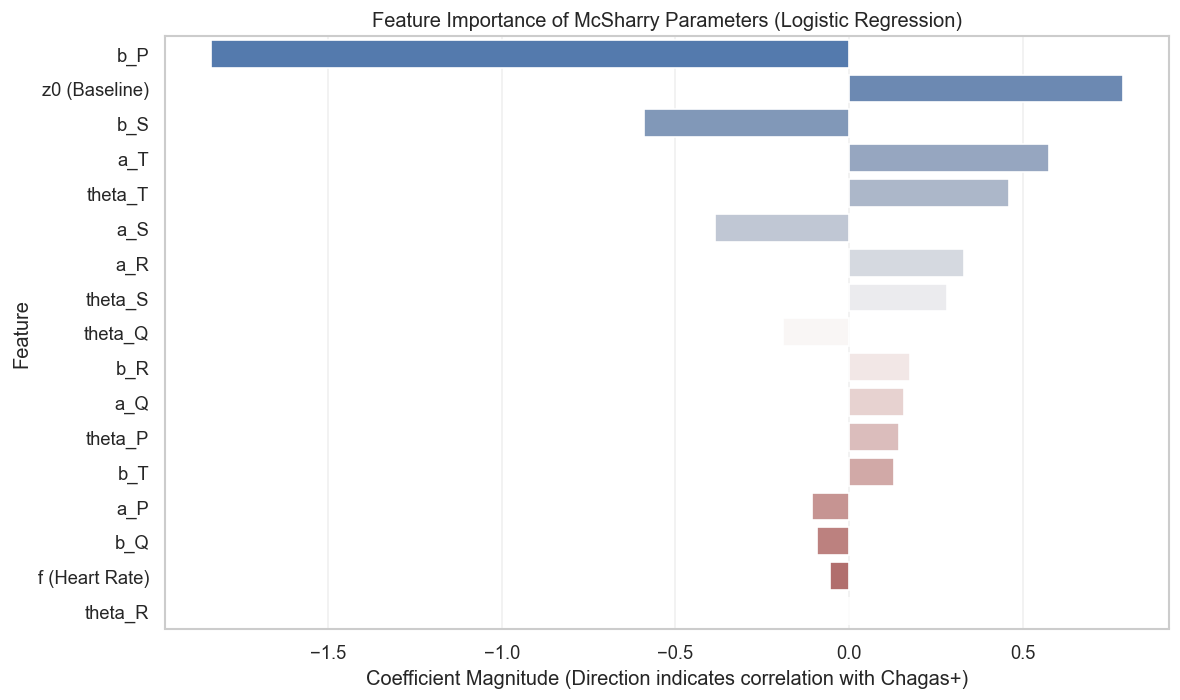

14:40:27 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
/var/folders/zf/8wzrl6dx2hqc67b9kdstrs0r0000gn/T/ipykernel_88617/3298391356.py:66: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_params, x='Chagas', y=feat, ax=axes[i], palette='Set2')
14:40:27 [INFO] Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
/var/folders/zf/8wzrl6dx2hqc67b9kdstrs0r0000gn/T/ipykernel_88617/3298391356.py:68: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Healt

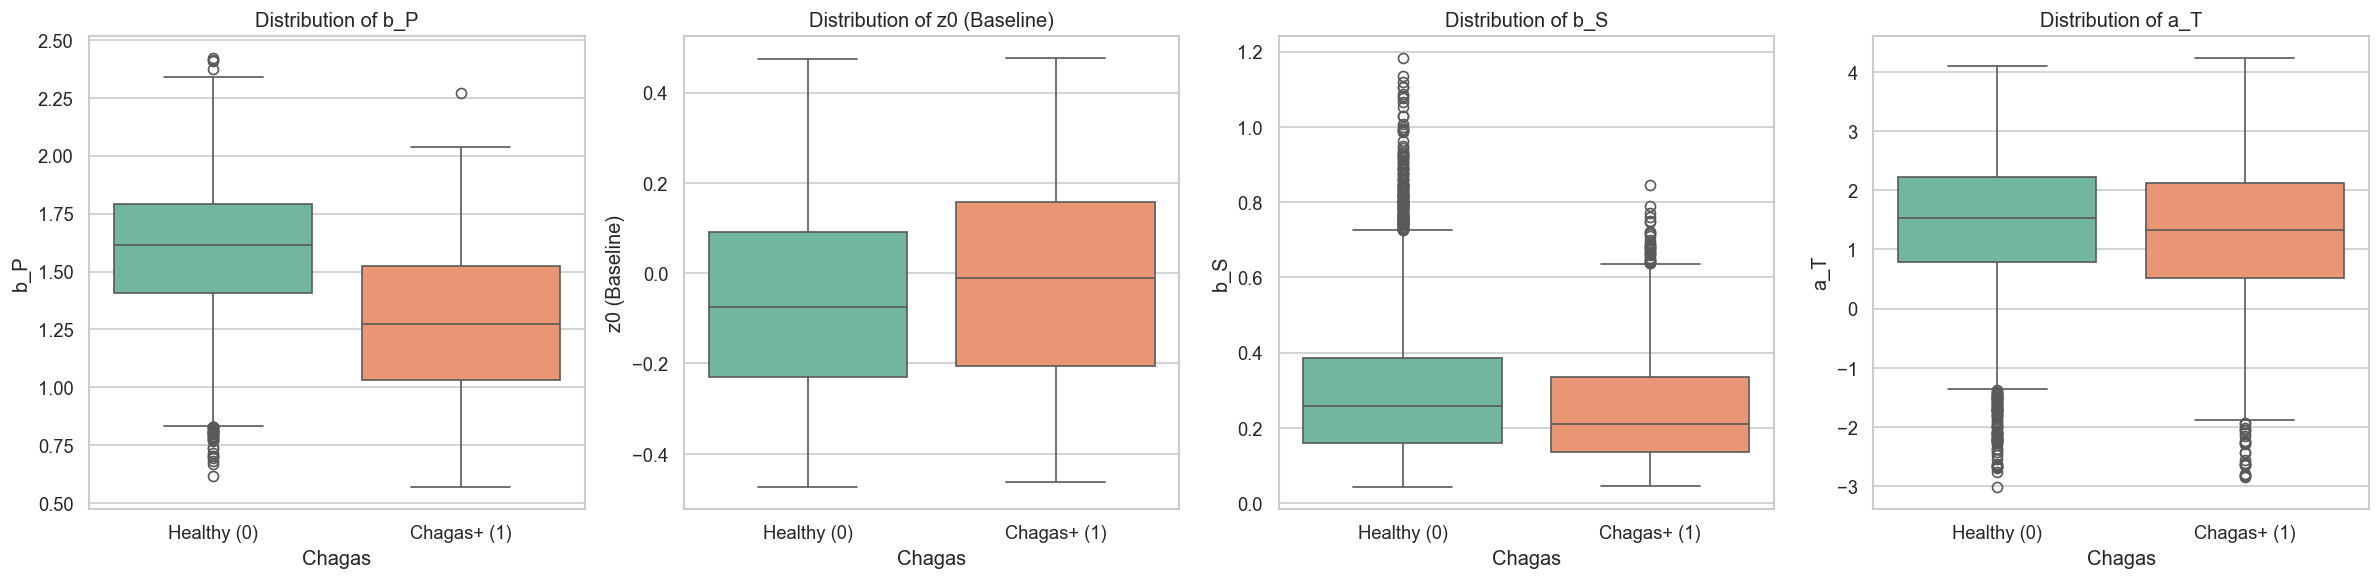

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

torch.save(model.state_dict(), 'approach10_mcsharry_best.pt')
print('Saved best model to approach10_mcsharry_best.pt')

model.eval()
val_params = []
val_labels = []

with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)
        _, params = model(x, return_params=True)
        val_params.append(params.cpu().numpy())
        val_labels.append(y.numpy())

val_params = np.concatenate(val_params, axis=0)
val_labels = np.concatenate(val_labels, axis=0)

param_names = [
    'f (Heart Rate)', 'z0 (Baseline)', 
    'a_P', 'a_Q', 'a_R', 'a_S', 'a_T', 
    'b_P', 'b_Q', 'b_R', 'b_S', 'b_T', 
    'theta_P', 'theta_Q', 'theta_R', 'theta_S', 'theta_T'
]

df_params = pd.DataFrame(val_params, columns=param_names)
df_params['Chagas'] = val_labels

scaler = StandardScaler()
X_scaled = scaler.fit_transform(val_params)

clf = LogisticRegression(max_iter=1000, class_weight='balanced')
clf.fit(X_scaled, val_labels)

importance = clf.coef_[0]
feat_imp = pd.DataFrame({'Feature': param_names, 'Importance': importance})
feat_imp['Abs_Importance'] = feat_imp['Importance'].abs()
feat_imp = feat_imp.sort_values(by='Abs_Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp, x='Importance', y='Feature', palette='vlag')
plt.title('Feature Importance of McSharry Parameters (Logistic Regression)')
plt.xlabel('Coefficient Magnitude (Direction indicates correlation with Chagas+)')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
import os
os.makedirs('approach10', exist_ok=True)
plt.savefig('approach10/feature_importance.png', dpi=300)
plt.show()

top_features = feat_imp['Feature'].head(4).tolist()

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for i, feat in enumerate(top_features):
    sns.boxplot(data=df_params, x='Chagas', y=feat, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Distribution of {feat}')
    axes[i].set_xticklabels(['Healthy (0)', 'Chagas+ (1)'])

plt.tight_layout()
plt.savefig('approach10/top_features_boxplots.png', dpi=300)
plt.show()

## Domain shift: CODE-15% vs SaMi-Trop

Compare the distributions of the extracted McSharry parameters between the in-domain validation set (CODE-15%) and the out-of-domain test set (SaMi-Trop) to check for distribution shift.

/var/folders/zf/8wzrl6dx2hqc67b9kdstrs0r0000gn/T/ipykernel_88617/114184420.py:31: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df_compare, x=param, hue='Domain', fill=True, ax=axes[i], common_norm=False, palette='muted')


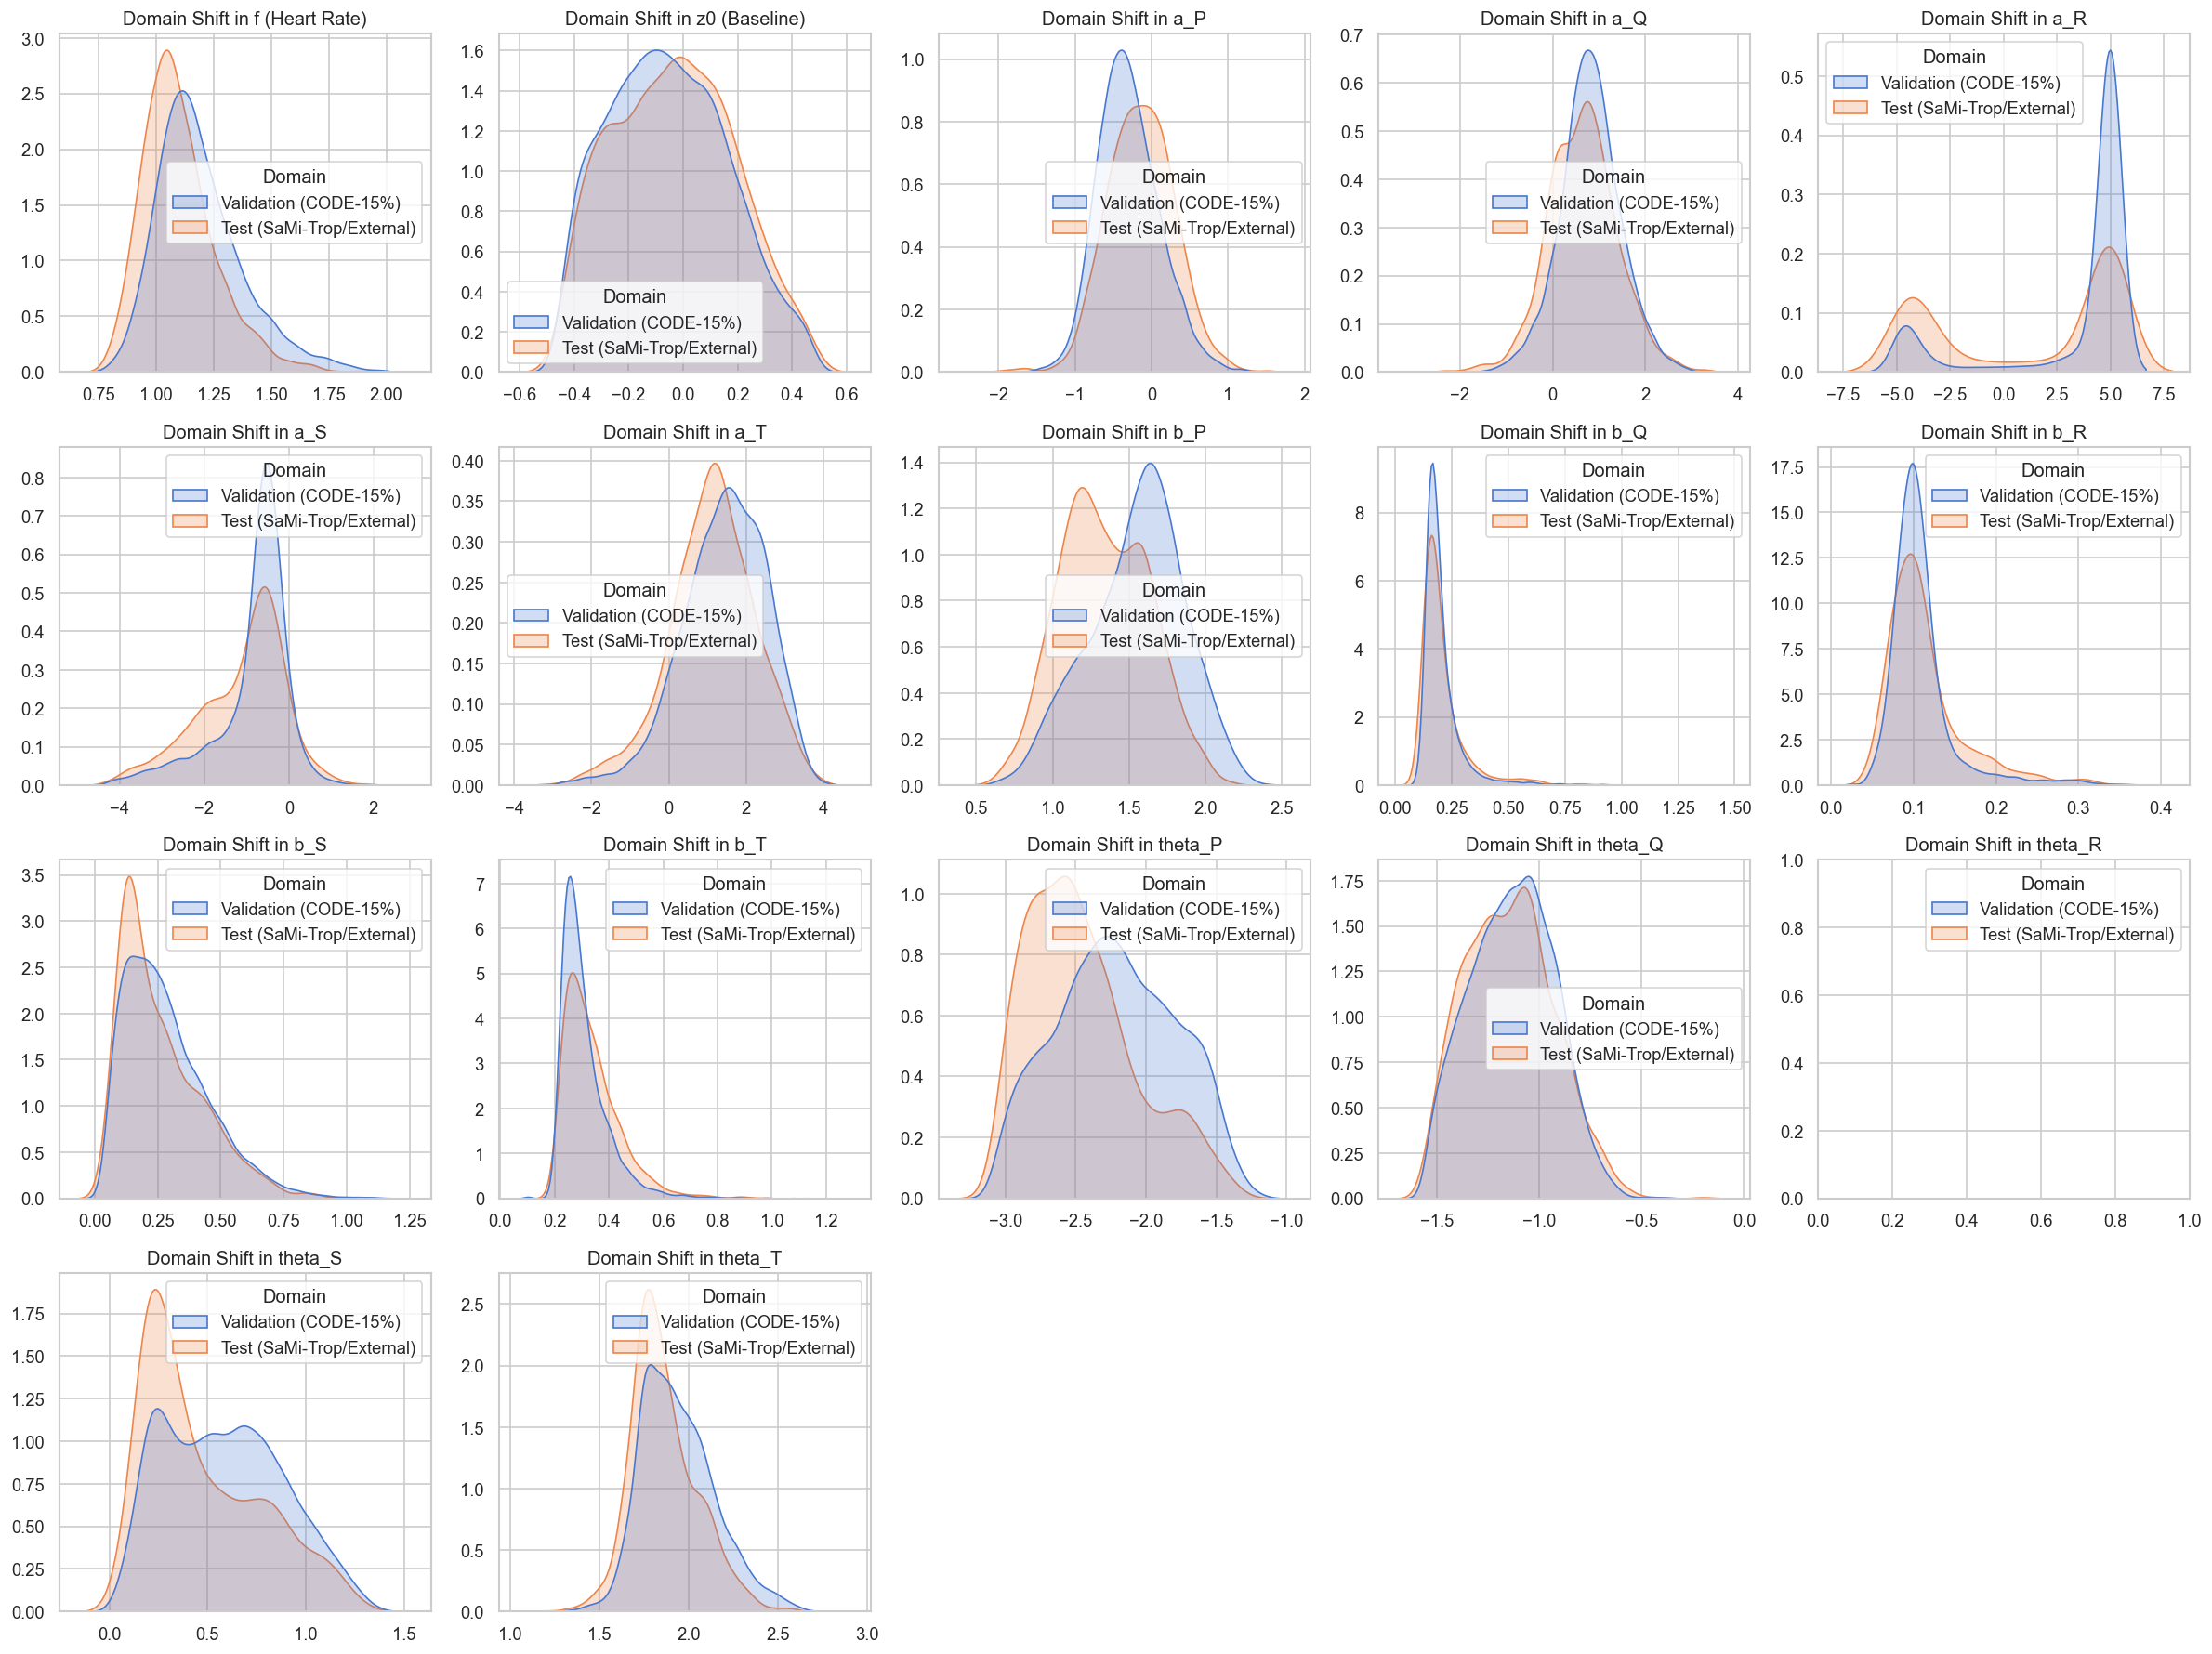

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

model.eval()
test_params = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        _, params = model(x, return_params=True)
        test_params.append(params.cpu().numpy())

test_params = np.concatenate(test_params, axis=0)

df_val = pd.DataFrame(val_params, columns=param_names)
df_val['Domain'] = 'Validation (CODE-15%)'

df_test = pd.DataFrame(test_params, columns=param_names)
df_test['Domain'] = 'Test (SaMi-Trop/External)'

df_compare = pd.concat([df_val, df_test], axis=0)

fig, axes = plt.subplots(4, 5, figsize=(20, 15))
axes = axes.flatten()

for i, param in enumerate(param_names):
    sns.kdeplot(data=df_compare, x=param, hue='Domain', fill=True, ax=axes[i], common_norm=False, palette='muted')
    axes[i].set_title(f'Domain Shift in {param}')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')

for j in range(len(param_names), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig('approach10/domain_shift_analysis.png', dpi=300)
plt.show()